## Ejemplo técnicas de deep learning
<div style="border-style:groove;border-width:thin;padding:10px">
Vamos a probar las técnicas de redes neuronales profundas vistas en clase para entrenar una red que distinga entre dos clases de pistachos.
</div>

<div style="border-style:groove;border-width:thin;padding:10px">

Puedes descargar el dataset en <a href="https://www.muratkoklu.com/datasets/">https://www.muratkoklu.com/datasets/</a>
    <p>Tienes dos carpetas con las imágenes para entrenar. Divide, como siempre, el dataset en train, test y validación.</p>
</div>

In [13]:
from os import listdir
from numpy import asarray
from numpy import save
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array

#Clase kirmizi será la clase 0.0
folder_kirmizi = 'Pistachio_Image_Dataset/Pistachio_Image_Dataset/Kirmizi_Pistachio/'
#Clase siirt será la clase 1.0
folder_siirt = 'Pistachio_Image_Dataset/Pistachio_Image_Dataset/Siirt_Pistachio/'
photos =  []
labels = []

for file in listdir(folder_kirmizi):
    #Cargamos la imagen.
    photo = load_img(folder_kirmizi + file, target_size=(400, 400), color_mode='grayscale')
    #Convertimos la imagen a un array.
    photo = img_to_array(photo)
    #Los guardamos en las listas.
    photos.append(photo)
    labels.append(0.0)

for file in listdir(folder_siirt):
    #Cargamos la imagen.
    photo = load_img(folder_siirt + file, target_size=(400, 400), color_mode='grayscale')
    #Convertimos la imagen a un array.
    photo = img_to_array(photo)
    #Los guardamos en las listas.
    photos.append(photo)
    labels.append(1.0)
    
#Convertimos la lista en un numpy array.
photos = asarray(photos)
labels = asarray(labels)
print(photos.shape, labels.shape)
#Como esto tarda mucho en hacerse vamos a guardar los datos en archivos. 
save('fotos_pistachos.npy', photos)
save('etiquetas_pistachos.npy', labels)


(2148, 400, 400, 1) (2148,)


<div style="border-style:groove;border-width:thin;padding:10px">
Os aconsejo que vayáis guardando la información: save('fotos_pistachos.npy', photos)
</div>

In [14]:
from numpy import load
photos = load('fotos_pistachos.npy')
labels = load('etiquetas_pistachos.npy')
print(photos.shape)

(2148, 400, 400, 1)


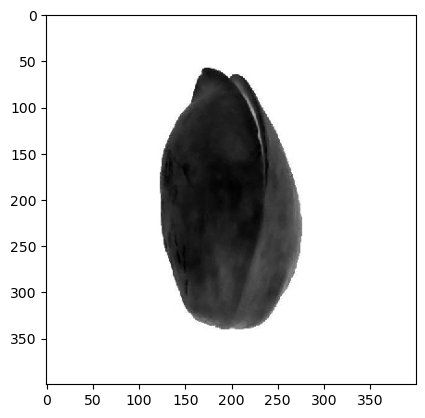

In [15]:
import matplotlib.pyplot as plt
plt.imshow(photos[0], cmap=plt.cm.binary) 

In [16]:
photos = photos.reshape(2148, 160000)

In [17]:
from sklearn.preprocessing import StandardScaler
escalador = StandardScaler()
X = photos
X = escalador.fit_transform(X)
y = labels

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 0)

1. Resuelve el problema con descenso de gradiente.

In [19]:
from tensorflow import keras


In [20]:
model = keras.models.Sequential()
model.add(keras.layers.InputLayer(input_shape=X_train.shape[1:]))
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dense(50,activation='relu'))
model.add(keras.layers.Dense(10,activation='relu'))
model.add(keras.layers.Dense(1,activation='sigmoid'))

/home/ciabd10/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [21]:
model.compile(loss='binary_crossentropy', optimizer = keras.optimizers.SGD(learning_rate=0.0001), metrics=['accuracy'])

In [22]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10,
restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100000,validation_split = 0.1,callbacks=[early_stopping_cb])

Epoch 1/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4773 - loss: 0.7042 - val_accuracy: 0.5258 - val_loss: 0.6438
Epoch 2/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5733 - loss: 0.6037 - val_accuracy: 0.5979 - val_loss: 0.6096
Epoch 3/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6584 - loss: 0.5651 - val_accuracy: 0.6598 - val_loss: 0.5889
Epoch 4/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7297 - loss: 0.5333 - val_accuracy: 0.7062 - val_loss: 0.5716
Epoch 5/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7849 - loss: 0.4969 - val_accuracy: 0.7577 - val_loss: 0.5442
Epoch 6/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8177 - loss: 0.4611 - val_accuracy: 0.7680 - val_loss: 0.5234
Epoch 7/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8327 - loss: 0.4311 - val_accuracy: 0.7732 - val_loss: 0.5050
Epoch 8/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8465 - loss: 0

In [23]:
model.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9070 - loss: 0.2126 


[0.21262292563915253, 0.9069767594337463]

2. Prueba con los distintos optimizadores (Adam, Nadam, RMSprop) que hemos visto en clase. Pon un callback para que pare cuando lleva 10 épocas sin mejorar. ¿Mejora el resultado respecto al descenso de gradiente?

In [24]:
#ADAM
model = keras.models.Sequential()
model.add(keras.layers.InputLayer(input_shape=X_train.shape[1:]))
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dense(50,activation='relu'))
model.add(keras.layers.Dense(10,activation='relu'))
model.add(keras.layers.Dense(1,activation='sigmoid'))

In [25]:
model.compile(loss='binary_crossentropy', optimizer = keras.optimizers.Adam(learning_rate=0.00001, beta_1=0.9, beta_2=0.999), metrics=['accuracy'])


In [26]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=20,
restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100000,validation_split = 0.1,callbacks=[early_stopping_cb])

Epoch 1/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.8062 - loss: 0.4991 - val_accuracy: 0.8711 - val_loss: 0.3703
Epoch 2/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.8884 - loss: 0.2858 - val_accuracy: 0.8454 - val_loss: 0.3586
Epoch 3/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.9258 - loss: 0.2117 - val_accuracy: 0.8866 - val_loss: 0.3501
Epoch 4/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.9431 - loss: 0.1700 - val_accuracy: 0.8660 - val_loss: 0.3450
Epoch 5/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.9603 - loss: 0.1344 - val_accuracy: 0.8557 - val_loss: 0.3366
Epoch 6/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.9718 - loss: 0.1075 - val_accuracy: 0.8711 - val_loss: 0.3487
Epoch 7/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.9810 - loss: 0.0841 - val_accuracy: 0.8711 - val_loss: 0.3513
Epoch 8/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.9850 - loss: 0

In [27]:
model.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8977 - loss: 0.3005 


[0.3005151152610779, 0.8976744413375854]

In [28]:
#RMSPROP
model = keras.models.Sequential()
model.add(keras.layers.InputLayer(input_shape=X_train.shape[1:]))
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dense(50,activation='relu'))
model.add(keras.layers.Dense(10,activation='relu'))
model.add(keras.layers.Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer = keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9), metrics=['accuracy'])

early_stopping_cb = keras.callbacks.EarlyStopping(patience=20,
restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100000,validation_split = 0.1,callbacks=[early_stopping_cb])


Epoch 1/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.7930 - loss: 5.1452 - val_accuracy: 0.7526 - val_loss: 8.7746
Epoch 2/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.8361 - loss: 2.6361 - val_accuracy: 0.7577 - val_loss: 4.6891
Epoch 3/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.8643 - loss: 1.8178 - val_accuracy: 0.8196 - val_loss: 4.7088
Epoch 4/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8873 - loss: 1.5076 - val_accuracy: 0.8557 - val_loss: 7.1970
Epoch 5/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9045 - loss: 1.4706 - val_accuracy: 0.8299 - val_loss: 2.5112
Epoch 6/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9086 - loss: 0.7608 - val_accuracy: 0.8660 - val_loss: 2.3748
Epoch 7/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9034 - loss: 0.9041 - val_accuracy: 0.8454 - val_loss: 4.1639
Epoch 8/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9160 - loss: 0

In [29]:
model.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8977 - loss: 1.1641 


[1.1641430854797363, 0.8976744413375854]

3. Prueba a cambiar el kernel_initializer de las capas en función de la función de activación de cada capa.

In [30]:
model = keras.models.Sequential()
model.add(keras.layers.InputLayer(shape=X_train.shape[1:]))
model.add(keras.layers.Dense(200,activation='relu',kernel_initializer='he_normal'))
model.add(keras.layers.Dense(50,activation='relu',kernel_initializer='he_normal'))
model.add(keras.layers.Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(keras.layers.Dense(1,activation='sigmoid',kernel_initializer='glorot_normal'))

model.compile(loss='binary_crossentropy', optimizer = keras.optimizers.Adam(learning_rate=0.0000001, beta_1=0.9, beta_2=0.999), metrics=['accuracy'])

early_stopping_cb = keras.callbacks.EarlyStopping(patience=30,
restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100000,validation_split = 0.1,callbacks=[early_stopping_cb])

Epoch 1/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.4583 - loss: 0.8389 - val_accuracy: 0.5309 - val_loss: 0.7862
Epoch 2/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.5279 - loss: 0.7520 - val_accuracy: 0.5773 - val_loss: 0.7307
Epoch 3/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.6061 - loss: 0.6856 - val_accuracy: 0.6237 - val_loss: 0.6847
Epoch 4/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.6647 - loss: 0.6320 - val_accuracy: 0.6701 - val_loss: 0.6474
Epoch 5/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.7039 - loss: 0.5888 - val_accuracy: 0.7062 - val_loss: 0.6177
Epoch 6/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.7372 - loss: 0.5535 - val_accuracy: 0.7216 - val_loss: 0.5945
Epoch 7/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.7619 - loss: 0.5237 - val_accuracy: 0.7423 - val_loss: 0.5714
Epoch 8/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.7763 -

In [31]:
history = model.fit(X_train, y_train, epochs=100000,validation_split = 0.1,callbacks=[early_stopping_cb])

Epoch 1/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.9672 - loss: 0.1202 - val_accuracy: 0.8402 - val_loss: 0.3666
Epoch 2/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.9678 - loss: 0.1191 - val_accuracy: 0.8402 - val_loss: 0.3667
Epoch 3/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.9678 - loss: 0.1181 - val_accuracy: 0.8402 - val_loss: 0.3663
Epoch 4/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.9672 - loss: 0.1171 - val_accuracy: 0.8402 - val_loss: 0.3667
Epoch 5/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.9684 - loss: 0.1161 - val_accuracy: 0.8402 - val_loss: 0.3664
Epoch 6/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.9689 - loss: 0.1152 - val_accuracy: 0.8402 - val_loss: 0.3660
Epoch 7/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - accuracy: 0.9689 - loss: 0.1143 - val_accuracy: 0.8402 - val_loss: 0.3668
Epoch 8/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - accuracy: 0.9695 -

In [ ]:
model.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.8544 - loss: 0.3642


[0.3191845715045929, 0.8651162981987]

4. Añade normalización entre las capas para que los resultados de una capa pasen normalizados a la siguiente.

In [12]:
model = keras.models.Sequential()
model.add(keras.layers.InputLayer(shape=X_train.shape[1:]))
model.add(keras.layers.Dense(100,activation='relu',kernel_initializer='he_normal'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(50,activation='relu',kernel_initializer='he_normal'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(1,activation='sigmoid',kernel_initializer='glorot_normal'))

model.compile(loss='binary_crossentropy', optimizer = keras.optimizers.Adamax(learning_rate=0.0000001, beta_1=0.9, beta_2=0.999), metrics=['accuracy'])

early_stopping_cb = keras.callbacks.EarlyStopping(patience=30,
restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100000,validation_split = 0.1,callbacks=[early_stopping_cb])

model.evaluate(X_test,y_test)

W0000 00:00:1774549688.500310   32635 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.4675 - loss: 0.8896 - val_accuracy: 0.4381 - val_loss: 0.7426
Epoch 2/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.4894 - loss: 0.8740 - val_accuracy: 0.4330 - val_loss: 0.7800
Epoch 3/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.4951 - loss: 0.8444 - val_accuracy: 0.4691 - val_loss: 0.7990
Epoch 4/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.5296 - loss: 0.8238 - val_accuracy: 0.4794 - val_loss: 0.8033
Epoch 5/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.5359 - loss: 0.7933 - val_accuracy: 0.4948 - val_loss: 0.7962
Epoch 6/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.5601 - loss: 0.7631 - val_accuracy: 0.5258 - val_loss: 0.7851
Epoch 7/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.5578 - loss: 0.7580 - val_accuracy: 0.5361 - val_loss: 0.7727
Epoch 8/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.5825 - loss: 0

[0.27051299810409546, 0.8976744413375854]